# Portfolio Assessment 1: Exploratory Data Analysis and Data Preparation

**Dataset:** House Prices - Advanced Regression Techniques (`train.csv`)  
**Target:** `SalePrice`  
**Primary problem:** Supervised regression

## Generative AI use declaration

> I used OpenAI Codex to assist with commenting code, debugging, suggesting feature combinations, improving code readability, and structuring the exploratory analysis. All final code, interpretations, and conclusions are my own work after verification.

This notebook performs a reproducible exploratory data analysis (EDA), assesses data quality, prepares the numerical target as balanced price bands, analyses individual predictors and their relationships, and interprets the findings from a housing-engineering perspective.

## 0. Setup and reproducibility

The path resolver allows the notebook to run from the repository root or from the notebook folder. The raw CSV is read without modification; all preparation is performed on a copy.

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.2f}")

sns.set_theme(style="whitegrid", context="notebook")
PALETTE = ["#2455A4", "#2E86AB", "#49A078", "#F18F01", "#C73E1D"]
TARGET = "SalePrice"


def find_repo_root(start: Path) -> Path:
    """Find the repository root from common notebook launch locations."""
    start = start.resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "data" / "house-price-prediction" / "train.csv").exists():
            return candidate
    raise FileNotFoundError("Could not locate data/house-price-prediction/train.csv")


REPO_ROOT = find_repo_root(Path.cwd())
DATA_DIR = REPO_ROOT / "data" / "house-price-prediction"
TRAIN_PATH = DATA_DIR / "train.csv"

print(f"Repository root: {REPO_ROOT}")
print(f"Dataset path:    {TRAIN_PATH}")

Repository root: C:\Users\Root\Documents\Swinburne\COS40007
Dataset path:    C:\Users\Root\Documents\Swinburne\COS40007\data\house-price-prediction\train.csv


## 1. Dataset loading and initial exploration

The supplied training dataset describes residential properties in Ames, Iowa. Each row represents a house sale. Predictors cover site geometry, dwelling type, material and finish quality, floor and basement area, amenities, age, and sale conditions. The target `SalePrice` is the recorded sale price in US dollars.

In [2]:
df = pd.read_csv(TRAIN_PATH)

print(f"Dataset shape: {df.shape[0]:,} rows x {df.shape[1]:,} columns")
print(f"Predictors: {df.shape[1] - 2} (excluding Id and {TARGET})")
display(df.head())

Dataset shape: 1,460 rows x 81 columns
Predictors: 79 (excluding Id and SalePrice)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.00,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.00,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,"2,003.00",RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.00,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.00,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,"1,976.00",RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.00,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.00,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,"2,001.00",RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.00,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.00,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,"1,998.00",Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.00,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.00,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,"2,000.00",RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [3]:
dtype_table = (
    df.dtypes.astype(str)
      .rename("DataType")
      .to_frame()
)
dtype_table["NonNull"] = df.notna().sum()
dtype_table["Missing"] = df.isna().sum()

print("Column data types:")
display(dtype_table)

print("Data-type counts:")
display(df.dtypes.astype(str).value_counts().rename("ColumnCount").to_frame())

Column data types:


,DataType,NonNull,Missing
Id,int64,1460,0
MSSubClass,int64,1460,0
MSZoning,str,1460,0
LotFrontage,float64,1201,259
LotArea,int64,1460,0
Street,str,1460,0
Alley,str,91,1369
LotShape,str,1460,0
LandContour,str,1460,0
Utilities,str,1460,0


Data-type counts:


,ColumnCount
str,43
int64,35
float64,3


In [4]:
print("Basic statistical summary of numerical columns:")
display(df.describe().T)

initial_missing = int(df.isna().sum().sum())
print(f"Initial missing-value check: {initial_missing:,} missing cells "
      f"({initial_missing / df.size:.2%} of all cells).")

Basic statistical summary of numerical columns:


,count,mean,std,min,25%,50%,75%,max
Id,"1,460.00",730.50,421.61,1.00,365.75,730.50,"1,095.25","1,460.00"
MSSubClass,"1,460.00",56.90,42.30,20.00,20.00,50.00,70.00,190.00
LotFrontage,"1,201.00",70.05,24.28,21.00,59.00,69.00,80.00,313.00
LotArea,"1,460.00","10,516.83","9,981.26","1,300.00","7,553.50","9,478.50","11,601.50","215,245.00"
OverallQual,"1,460.00",6.10,1.38,1.00,5.00,6.00,7.00,10.00
OverallCond,"1,460.00",5.58,1.11,1.00,5.00,5.00,6.00,9.00
YearBuilt,"1,460.00","1,971.27",30.20,"1,872.00","1,954.00","1,973.00","2,000.00","2,010.00"
YearRemodAdd,"1,460.00","1,984.87",20.65,"1,950.00","1,967.00","1,994.00","2,004.00","2,010.00"
MasVnrArea,"1,452.00",103.69,181.07,0.00,0.00,0.00,166.00,"1,600.00"
BsmtFinSF1,"1,460.00",443.64,456.10,0.00,0.00,383.50,712.25,"5,644.00"


Initial missing-value check: 7,829 missing cells (6.62% of all cells).


**Initial observation.** The dataset is tabular and mixed-type: continuous measurements, integer counts/ratings, and categorical descriptors. `Id` is an identifier rather than an engineering predictor and is excluded from correlation and modelling-oriented analyses. The target is complete, so no outcome rows need to be removed.

## 2. Data quality assessment

Missing values, duplicates, and outliers are assessed separately. In this dataset, a blank field can mean either an unrecorded value or the physical absence of a feature (for example, no alley, pool, fireplace, basement, or garage). Treating every blank as an error would therefore discard useful engineering information.

In [5]:
missing_table = pd.DataFrame({
    "MissingCount": df.isna().sum(),
    "MissingPercent": df.isna().mean().mul(100)
}).query("MissingCount > 0").sort_values("MissingPercent", ascending=False)

print(f"Columns with missing values: {len(missing_table)}")
display(missing_table)

Columns with missing values: 19


,MissingCount,MissingPercent
PoolQC,1453,99.52
MiscFeature,1406,96.30
Alley,1369,93.77
Fence,1179,80.75
MasVnrType,872,59.73
FireplaceQu,690,47.26
LotFrontage,259,17.74
GarageType,81,5.55
GarageYrBlt,81,5.55
GarageFinish,81,5.55


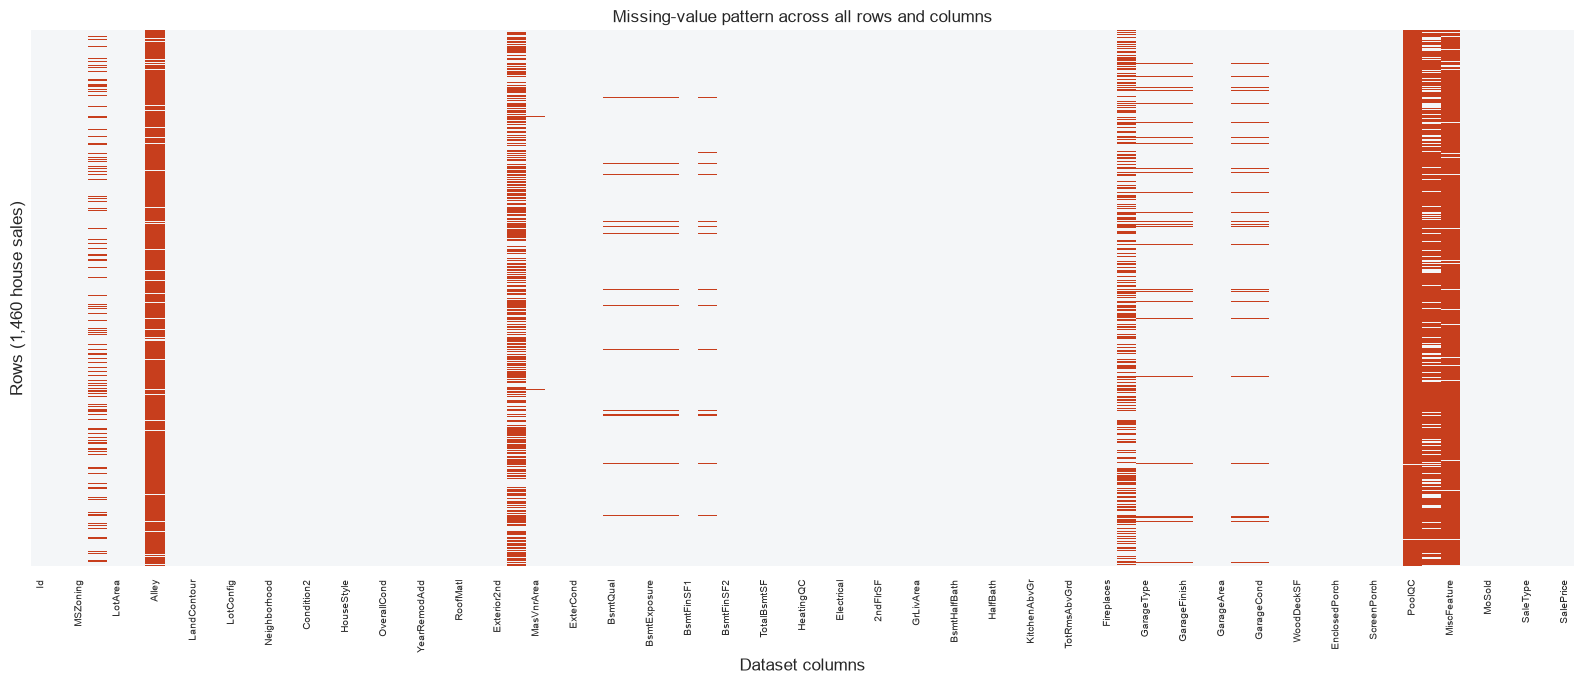

In [6]:
plt.figure(figsize=(16, 7))
sns.heatmap(df.isna(), cbar=False, yticklabels=False, cmap=["#F4F6F8", "#C73E1D"])
plt.title("Missing-value pattern across all rows and columns")
plt.xlabel("Dataset columns")
plt.ylabel("Rows (1,460 house sales)")
plt.xticks(rotation=90, fontsize=7)
plt.tight_layout()
plt.show()

In [7]:
duplicate_count = int(df.duplicated().sum())
duplicate_without_id = int(df.drop(columns="Id").duplicated().sum())
print(f"Exact duplicate rows (including Id): {duplicate_count}")
print(f"Duplicate property records (excluding Id): {duplicate_without_id}")

if duplicate_without_id:
    display(df[df.drop(columns="Id").duplicated(keep=False)].head(10))
else:
    print("No duplicate examples are available because no duplicates were found.")

Exact duplicate rows (including Id): 0
Duplicate property records (excluding Id): 0
No duplicate examples are available because no duplicates were found.


In [8]:
numeric_predictors = [
    column for column in df.select_dtypes(include=np.number).columns
    if column not in ["Id", TARGET]
]

q1 = df[numeric_predictors].quantile(0.25)
q3 = df[numeric_predictors].quantile(0.75)
iqr = q3 - q1
outlier_mask = (
    df[numeric_predictors].lt(q1 - 1.5 * iqr)
    | df[numeric_predictors].gt(q3 + 1.5 * iqr)
)
outlier_summary = (
    outlier_mask.sum()
    .rename("IQR_OutlierCount")
    .to_frame()
    .assign(OutlierPercent=lambda table: table["IQR_OutlierCount"] / len(df) * 100)
    .sort_values("IQR_OutlierCount", ascending=False)
)

print("IQR-based outlier counts for numerical predictors:")
display(outlier_summary)

IQR-based outlier counts for numerical predictors:


,IQR_OutlierCount,OutlierPercent
EnclosedPorch,208,14.25
BsmtFinSF2,167,11.44
OverallCond,125,8.56
ScreenPorch,116,7.95
MSSubClass,103,7.05
MasVnrArea,96,6.58
LotFrontage,88,6.03
BsmtHalfBath,82,5.62
OpenPorchSF,77,5.27
LotArea,69,4.73


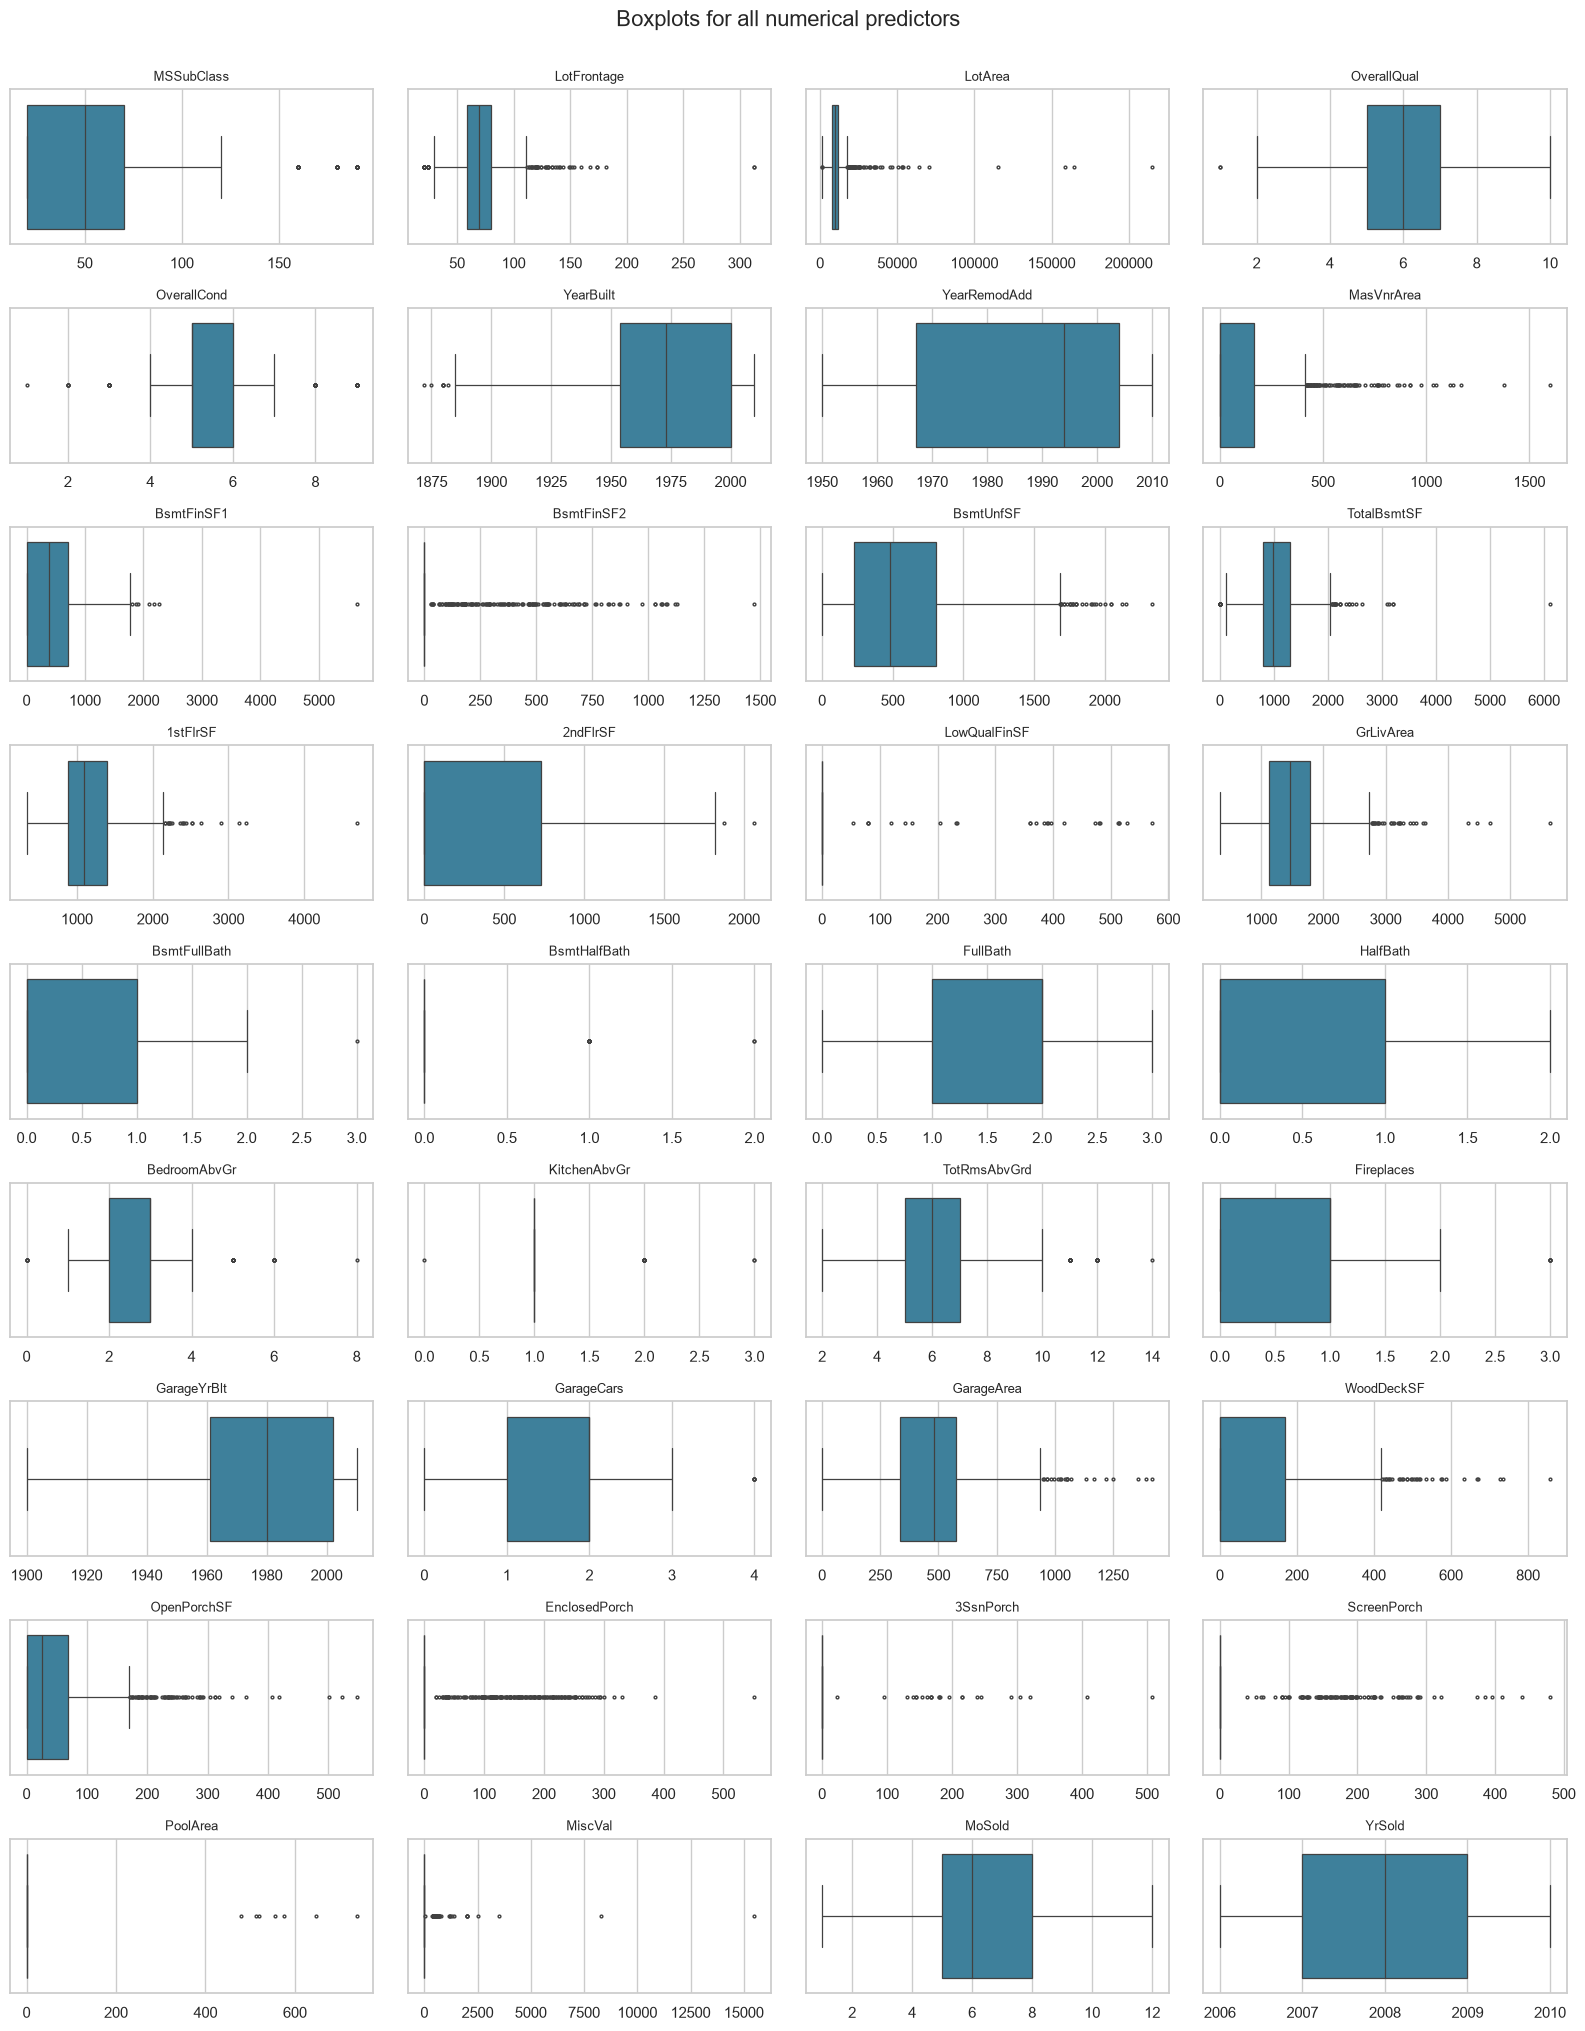

In [9]:
n_cols = 4
n_rows = int(np.ceil(len(numeric_predictors) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 2.25 * n_rows))

for axis, column in zip(axes.flat, numeric_predictors):
    sns.boxplot(x=df[column], ax=axis, color="#2E86AB", fliersize=2, linewidth=0.9)
    axis.set_title(column, fontsize=9)
    axis.set_xlabel("")

for axis in axes.flat[len(numeric_predictors):]:
    axis.set_visible(False)

fig.suptitle("Boxplots for all numerical predictors", fontsize=16, y=1.002)
plt.tight_layout()
plt.show()

In [10]:
large_homes = df.loc[df["GrLivArea"] > 4000, ["Id", "GrLivArea", TARGET, "OverallQual"]]
print("Very large above-ground living areas (>4,000 sq ft):")
display(large_homes.sort_values("GrLivArea", ascending=False))

Very large above-ground living areas (>4,000 sq ft):


,Id,GrLivArea,SalePrice,OverallQual
1298,1299,5642,160000,10
523,524,4676,184750,10
1182,1183,4476,745000,10
691,692,4316,755000,10


**Data-quality observations.** No duplicate sales were detected. Missingness is concentrated in a small set of optional property features; the highest rates occur where the feature is usually absent, not necessarily unknown. The IQR rule flags many zero-inflated variables (porches, low-frequency amenities, and secondary basement area), so automatic row deletion would remove valid housing configurations. Two houses above 4,000 square feet have unusually low sale prices relative to their size and should receive sensitivity checks during modelling. For this EDA, observations are retained and flags are preferred to irreversible deletion.

## 3. Target variable preparation

`SalePrice` is a continuous numeric target, so the natural predictive task is regression. To satisfy the assessment requirement for numerical targets, it is also discretised into four price bands using equal-frequency (quartile) binning. Quartiles are selected because they yield interpretable market tiers with approximately equal sample sizes; equal-width bins would be dominated by the right tail and produce severe class imbalance.

In [11]:
print(f"Target variable: {TARGET}")
print(f"Data type:       {df[TARGET].dtype}")
print("Problem type:    Regression (with supplemental quartile classes)")
display(df[TARGET].describe().rename("SalePrice summary").to_frame())

class_labels = ["Entry", "Affordable", "Premium", "Luxury"]
sale_price_class, class_edges = pd.qcut(
    df[TARGET], q=4, labels=class_labels, retbins=True, duplicates="drop"
)
df_analysis = df.copy()
df_analysis["SalePriceClass"] = sale_price_class

class_boundaries = pd.DataFrame({
    "Class": class_labels,
    "LowerExclusiveApprox": class_edges[:-1],
    "UpperInclusive": class_edges[1:],
})
class_distribution = (
    df_analysis["SalePriceClass"].value_counts(sort=False)
    .rename("Count").to_frame()
    .assign(Percent=lambda table: table["Count"] / len(df_analysis) * 100)
)

print("Quartile class boundaries (USD):")
display(class_boundaries)
print("Class distribution:")
display(class_distribution)

Target variable: SalePrice
Data type:       int64
Problem type:    Regression (with supplemental quartile classes)


,SalePrice summary
count,"1,460.00"
mean,"180,921.20"
std,"79,442.50"
min,"34,900.00"
25%,"129,975.00"
50%,"163,000.00"
75%,"214,000.00"
max,"755,000.00"


Quartile class boundaries (USD):


,Class,LowerExclusiveApprox,UpperInclusive
0,Entry,"34,900.00","129,975.00"
1,Affordable,"129,975.00","163,000.00"
2,Premium,"163,000.00","214,000.00"
3,Luxury,"214,000.00","755,000.00"


Class distribution:


,Count,Percent
SalePriceClass,,
Entry,365,25.00
Affordable,367,25.14
Premium,366,25.07
Luxury,362,24.79


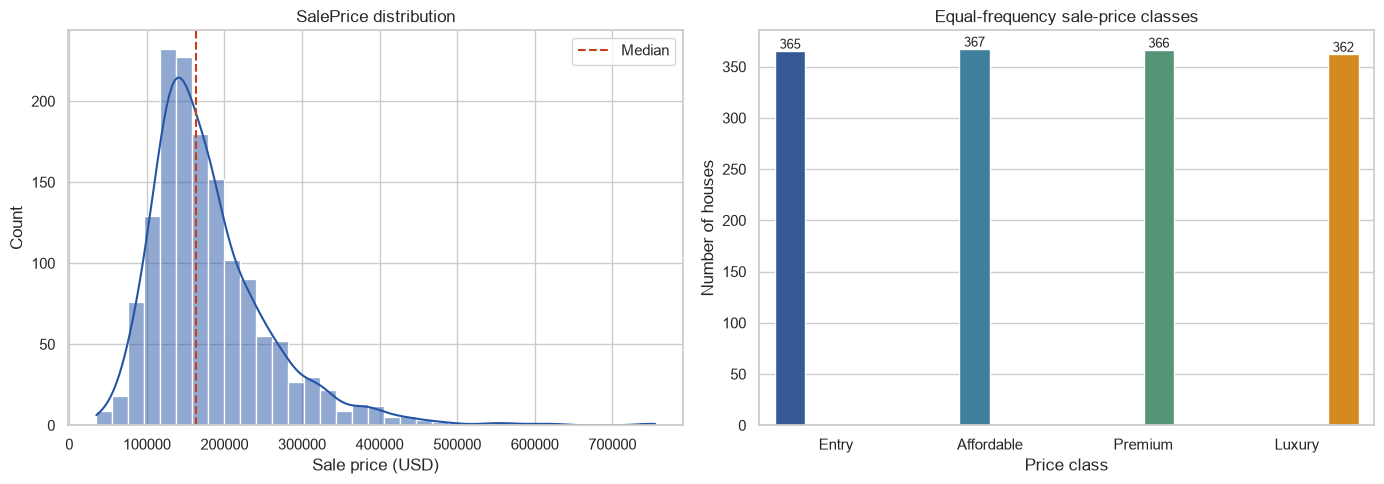

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df[TARGET], bins=35, kde=True, ax=axes[0], color=PALETTE[0])
axes[0].axvline(df[TARGET].median(), color=PALETTE[4], linestyle="--", label="Median")
axes[0].set_title("SalePrice distribution")
axes[0].set_xlabel("Sale price (USD)")
axes[0].legend()

sns.countplot(
    data=df_analysis, x="SalePriceClass", order=class_labels,
    ax=axes[1], hue="SalePriceClass", palette=PALETTE[:4], legend=False
)
axes[1].set_title("Equal-frequency sale-price classes")
axes[1].set_xlabel("Price class")
axes[1].set_ylabel("Number of houses")

for patch in axes[1].patches:
    axes[1].annotate(
        f"{int(patch.get_height())}",
        (patch.get_x() + patch.get_width() / 2, patch.get_height()),
        ha="center", va="bottom", fontsize=9
    )

plt.tight_layout()
plt.show()

**Target observations.** `SalePrice` is strongly right-skewed: most homes are in the lower and middle price ranges, while a small number of high-value properties extend the upper tail. The median is therefore lower than the mean. A logarithmic target transformation is a reasonable modelling candidate because it can stabilise variance and reduce the influence of extreme prices. The four supplemental classes are balanced by design, with small count differences caused by tied prices at quantile boundaries.

## 4. Univariate analysis

There are 79 predictors after excluding the identifier and target. The complete list is shown below, followed by descriptive tables for every numeric and categorical predictor. Distribution plots focus on eight engineering-relevant numeric predictors, exceeding the minimum requirement of six.

In [13]:
predictors = [column for column in df.columns if column not in ["Id", TARGET]]
categorical_predictors = df[predictors].select_dtypes(exclude=np.number).columns.tolist()

print(f"All predictors ({len(predictors)}):")
for start in range(0, len(predictors), 6):
    print("  " + ", ".join(predictors[start:start + 6]))

print(f"\nNumerical predictors: {len(numeric_predictors)}")
print(f"Categorical predictors: {len(categorical_predictors)}")

All predictors (79):
  MSSubClass, MSZoning, LotFrontage, LotArea, Street, Alley
  LotShape, LandContour, Utilities, LotConfig, LandSlope, Neighborhood
  Condition1, Condition2, BldgType, HouseStyle, OverallQual, OverallCond
  YearBuilt, YearRemodAdd, RoofStyle, RoofMatl, Exterior1st, Exterior2nd
  MasVnrType, MasVnrArea, ExterQual, ExterCond, Foundation, BsmtQual
  BsmtCond, BsmtExposure, BsmtFinType1, BsmtFinSF1, BsmtFinType2, BsmtFinSF2
  BsmtUnfSF, TotalBsmtSF, Heating, HeatingQC, CentralAir, Electrical
  1stFlrSF, 2ndFlrSF, LowQualFinSF, GrLivArea, BsmtFullBath, BsmtHalfBath
  FullBath, HalfBath, BedroomAbvGr, KitchenAbvGr, KitchenQual, TotRmsAbvGrd
  Functional, Fireplaces, FireplaceQu, GarageType, GarageYrBlt, GarageFinish
  GarageCars, GarageArea, GarageQual, GarageCond, PavedDrive, WoodDeckSF
  OpenPorchSF, EnclosedPorch, 3SsnPorch, ScreenPorch, PoolArea, PoolQC
  Fence, MiscFeature, MiscVal, MoSold, YrSold, SaleType
  SaleCondition

Numerical predictors: 36
Categorical predic

In [14]:
numeric_summary = df[numeric_predictors].describe().T
numeric_summary["missing"] = df[numeric_predictors].isna().sum()
numeric_summary["skew"] = df[numeric_predictors].skew()
print("Summary statistics for all numerical predictors:")
display(numeric_summary)

categorical_summary = df[categorical_predictors].describe(include="all").T
categorical_summary["missing"] = df[categorical_predictors].isna().sum()
print("Summary statistics for all categorical predictors:")
display(categorical_summary)

Summary statistics for all numerical predictors:


,count,mean,std,min,25%,50%,75%,max,missing,skew
MSSubClass,"1,460.00",56.90,42.30,20.00,20.00,50.00,70.00,190.00,0,1.41
LotFrontage,"1,201.00",70.05,24.28,21.00,59.00,69.00,80.00,313.00,259,2.16
LotArea,"1,460.00","10,516.83","9,981.26","1,300.00","7,553.50","9,478.50","11,601.50","215,245.00",0,12.21
OverallQual,"1,460.00",6.10,1.38,1.00,5.00,6.00,7.00,10.00,0,0.22
OverallCond,"1,460.00",5.58,1.11,1.00,5.00,5.00,6.00,9.00,0,0.69
YearBuilt,"1,460.00","1,971.27",30.20,"1,872.00","1,954.00","1,973.00","2,000.00","2,010.00",0,-0.61
YearRemodAdd,"1,460.00","1,984.87",20.65,"1,950.00","1,967.00","1,994.00","2,004.00","2,010.00",0,-0.50
MasVnrArea,"1,452.00",103.69,181.07,0.00,0.00,0.00,166.00,"1,600.00",8,2.67
BsmtFinSF1,"1,460.00",443.64,456.10,0.00,0.00,383.50,712.25,"5,644.00",0,1.69
BsmtFinSF2,"1,460.00",46.55,161.32,0.00,0.00,0.00,0.00,"1,474.00",0,4.26


Summary statistics for all categorical predictors:


,count,unique,top,freq,missing
MSZoning,1460,5,RL,1151,0
Street,1460,2,Pave,1454,0
Alley,91,2,Grvl,50,1369
LotShape,1460,4,Reg,925,0
LandContour,1460,4,Lvl,1311,0
Utilities,1460,2,AllPub,1459,0
LotConfig,1460,5,Inside,1052,0
LandSlope,1460,3,Gtl,1382,0
Neighborhood,1460,25,NAmes,225,0
Condition1,1460,9,Norm,1260,0


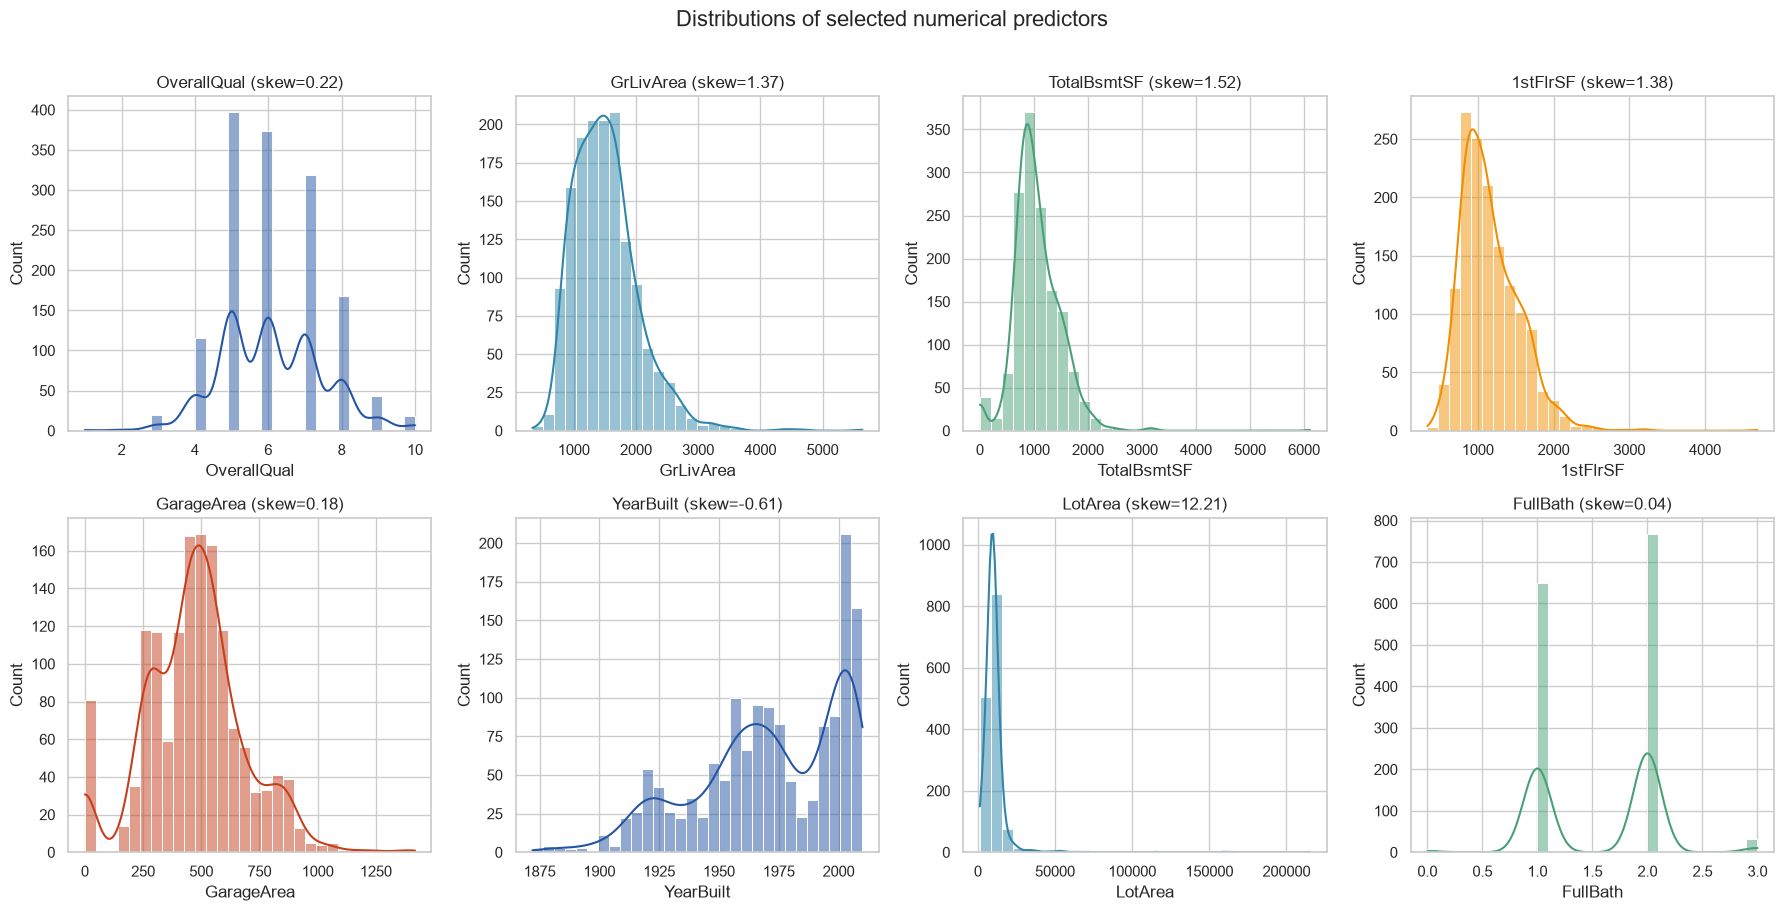

In [15]:
selected_numeric = [
    "OverallQual", "GrLivArea", "TotalBsmtSF", "1stFlrSF",
    "GarageArea", "YearBuilt", "LotArea", "FullBath"
]

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
for axis, column, color in zip(axes.flat, selected_numeric, PALETTE * 2):
    sns.histplot(df[column], bins=30, kde=True, ax=axis, color=color)
    axis.set_title(f"{column} (skew={df[column].skew():.2f})")
    axis.set_ylabel("Count")

fig.suptitle("Distributions of selected numerical predictors", fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

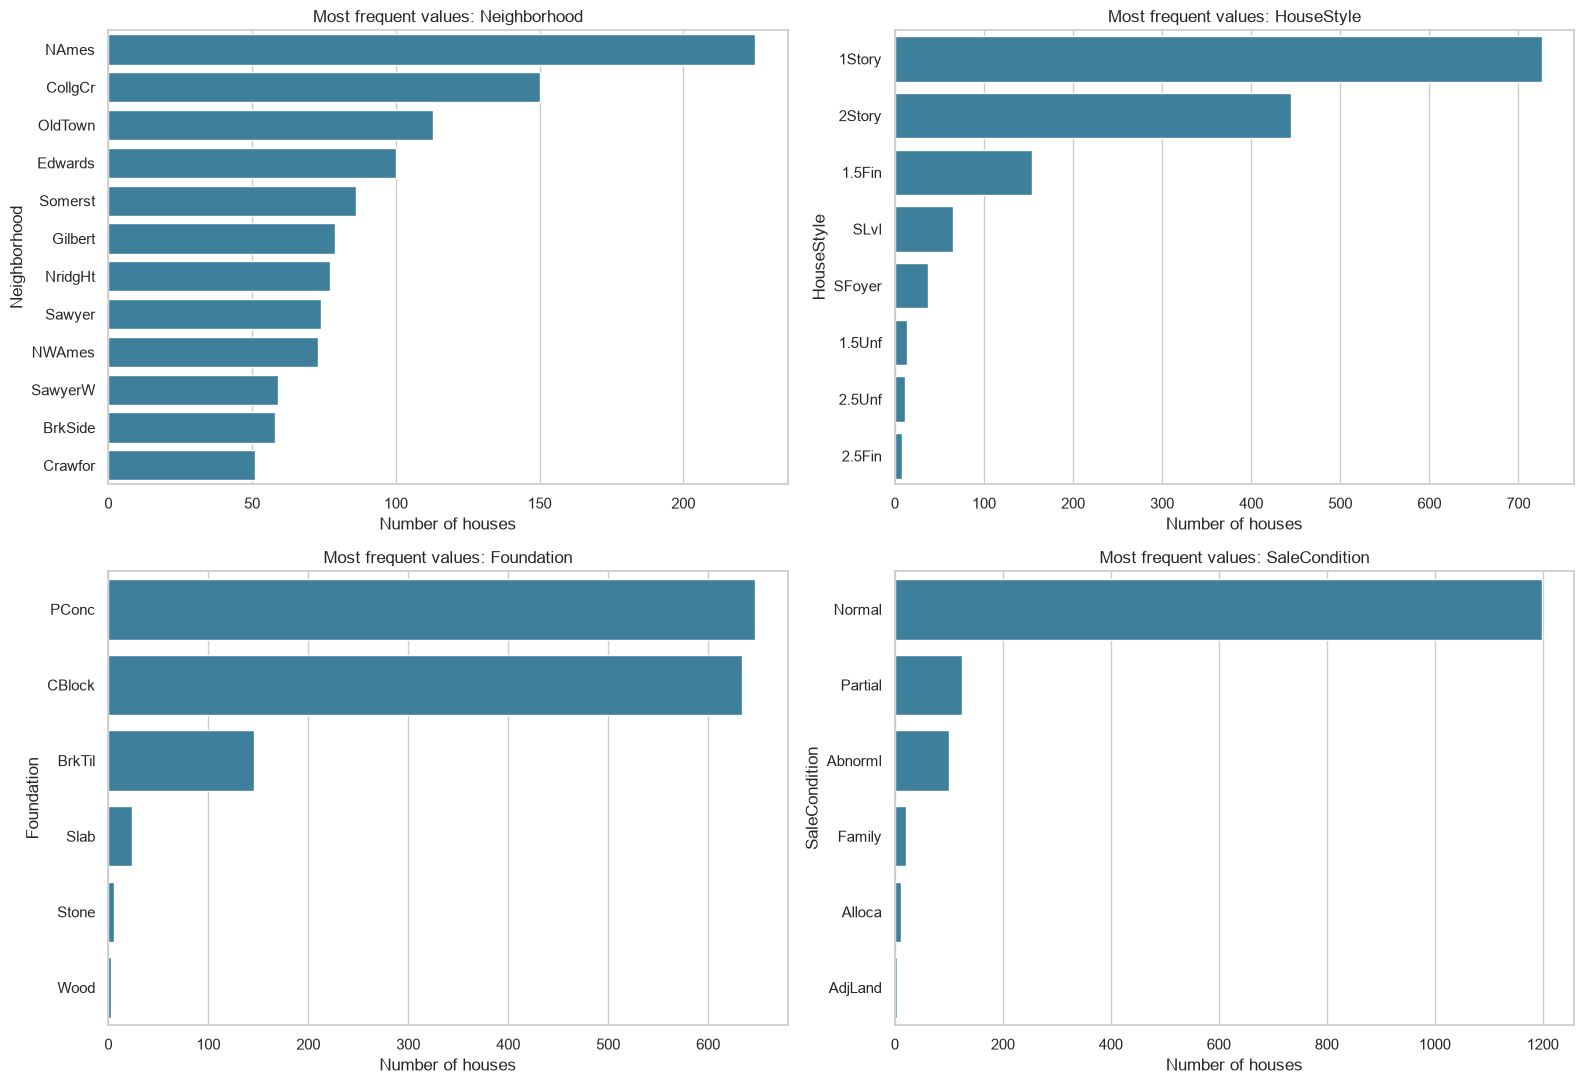

In [16]:
selected_categorical = ["Neighborhood", "HouseStyle", "Foundation", "SaleCondition"]
fig, axes = plt.subplots(2, 2, figsize=(16, 11))

for axis, column in zip(axes.flat, selected_categorical):
    order = df[column].value_counts().head(12).index
    sns.countplot(data=df, y=column, order=order, ax=axis, color="#2E86AB")
    axis.set_title(f"Most frequent values: {column}")
    axis.set_xlabel("Number of houses")
    axis.set_ylabel(column)

plt.tight_layout()
plt.show()

**Univariate observations.** `OverallQual` is centred around ratings 5-7, while `GarageArea` is comparatively close to symmetric. `LotArea`, `GrLivArea`, `TotalBsmtSF`, and `1stFlrSF` are right-skewed because a minority of properties are substantially larger. `YearBuilt` is left-skewed toward newer construction, but the long historical tail suggests that age effects may be nonlinear. Several count and amenity variables are zero-inflated because many houses lack that feature. Categorical predictors are also imbalanced: common neighbourhoods and conventional house styles occur much more often than rare categories, so encoding must handle infrequent levels carefully.

## 5. Multivariate analysis

Pearson correlations are used as a first-pass measure of linear association among numeric variables. They do not capture nonlinear relationships and do not establish causality. Categorical predictors require encoding or category-specific comparisons and are therefore not present in this numeric correlation matrix.

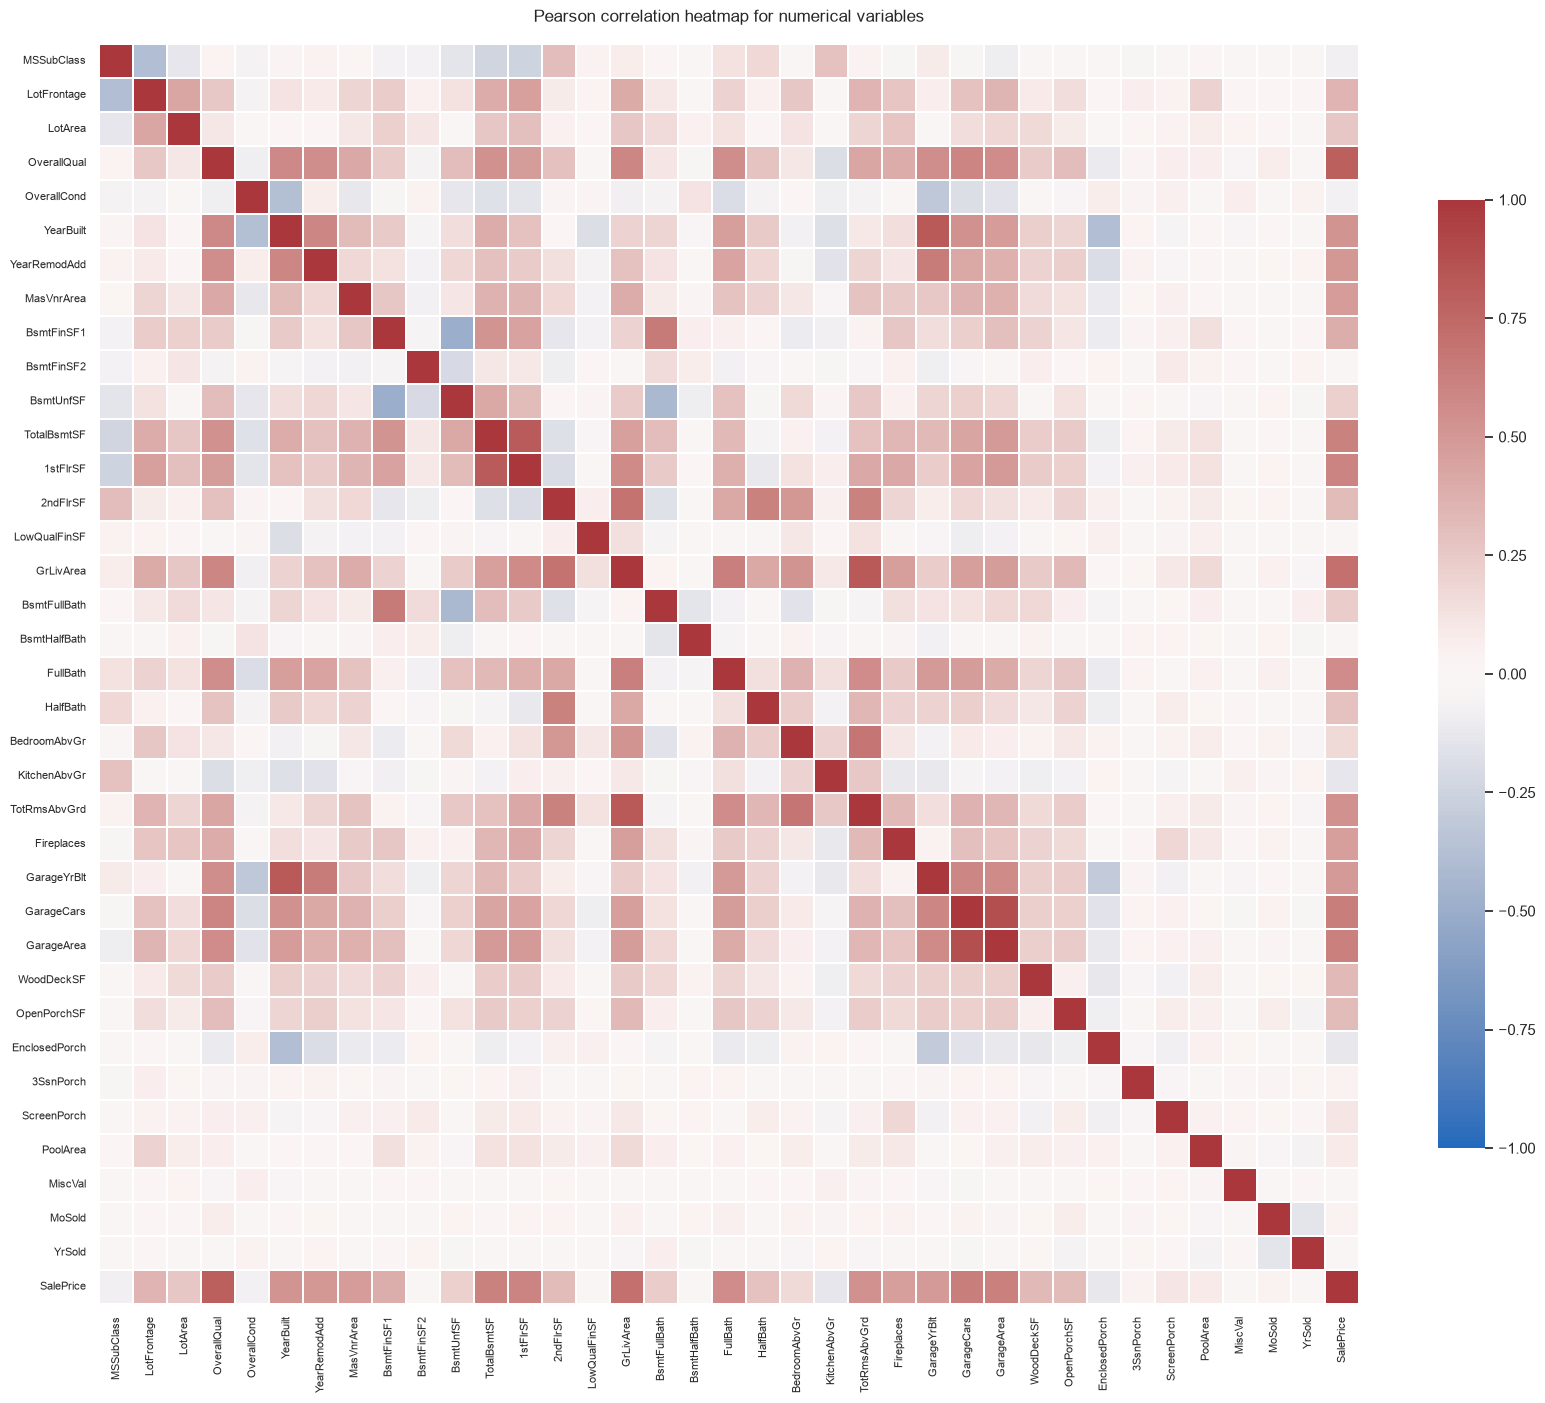

In [17]:
correlation_columns = [column for column in df.select_dtypes(include=np.number).columns if column != "Id"]
corr_matrix = df[correlation_columns].corr()

plt.figure(figsize=(17, 14))
sns.heatmap(
    corr_matrix, cmap="vlag", center=0, vmin=-1, vmax=1,
    square=True, linewidths=0.15, cbar_kws={"shrink": 0.75}
)
plt.title("Pearson correlation heatmap for numerical variables", pad=16)
plt.xticks(rotation=90, fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()

Top numerical features correlated with SalePrice:


,CorrelationWithSalePrice
OverallQual,0.79
GrLivArea,0.71
GarageCars,0.64
GarageArea,0.62
TotalBsmtSF,0.61
1stFlrSF,0.61
FullBath,0.56
TotRmsAbvGrd,0.53
YearBuilt,0.52
YearRemodAdd,0.51


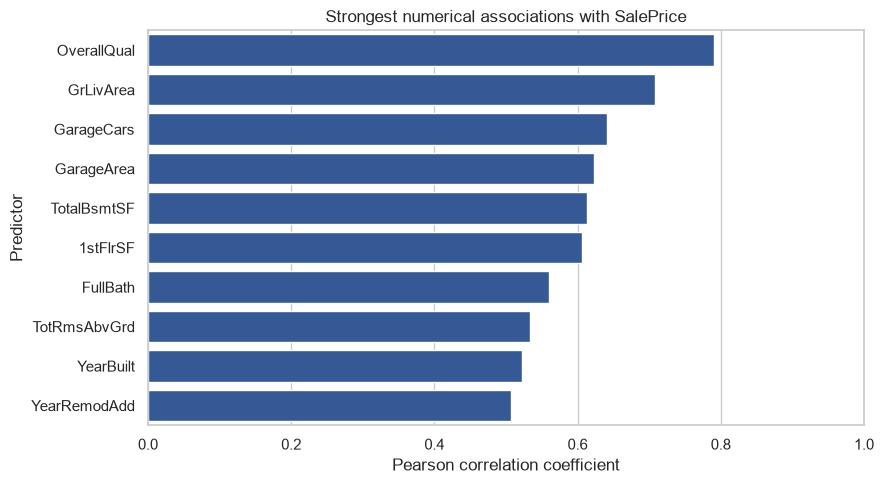

In [18]:
target_correlations = (
    corr_matrix[TARGET].drop(TARGET)
    .sort_values(key=np.abs, ascending=False)
)
top_target_features = target_correlations.head(10).rename("CorrelationWithSalePrice").to_frame()

print("Top numerical features correlated with SalePrice:")
display(top_target_features)

plt.figure(figsize=(9, 5))
sns.barplot(
    x=top_target_features["CorrelationWithSalePrice"],
    y=top_target_features.index,
    color="#2455A4"
)
plt.title("Strongest numerical associations with SalePrice")
plt.xlabel("Pearson correlation coefficient")
plt.ylabel("Predictor")
plt.xlim(0, 1)
plt.tight_layout()
plt.show()

In [19]:
predictor_corr = df[numeric_predictors].corr().abs()
upper_triangle = predictor_corr.where(np.triu(np.ones(predictor_corr.shape), k=1).astype(bool))
high_corr_pairs = (
    upper_triangle.stack()
    .rename("AbsoluteCorrelation")
    .reset_index()
    .rename(columns={"level_0": "PredictorA", "level_1": "PredictorB"})
    .query("AbsoluteCorrelation >= 0.70")
    .sort_values("AbsoluteCorrelation", ascending=False)
    .reset_index(drop=True)
)

print("Potential multicollinearity pairs (|r| >= 0.70):")
display(high_corr_pairs)

Potential multicollinearity pairs (|r| >= 0.70):


,PredictorA,PredictorB,AbsoluteCorrelation
0,GarageCars,GarageArea,0.88
1,YearBuilt,GarageYrBlt,0.83
2,GrLivArea,TotRmsAbvGrd,0.83
3,TotalBsmtSF,1stFlrSF,0.82


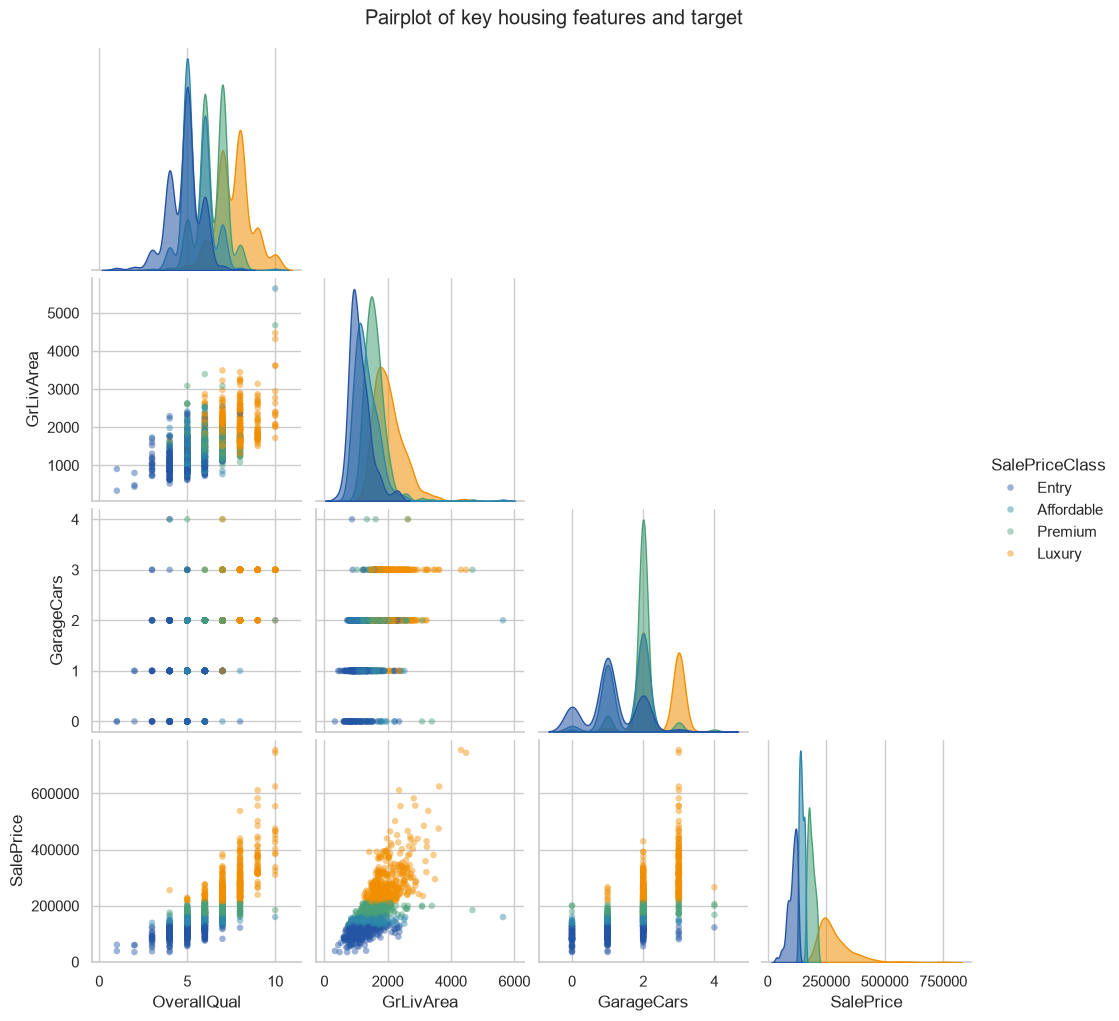

In [20]:
pairplot_columns = ["OverallQual", "GrLivArea", "GarageCars", TARGET, "SalePriceClass"]
pair_grid = sns.pairplot(
    df_analysis[pairplot_columns],
    vars=["OverallQual", "GrLivArea", "GarageCars", TARGET],
    hue="SalePriceClass",
    hue_order=class_labels,
    palette=PALETTE[:4],
    corner=True,
    plot_kws={"alpha": 0.45, "s": 22, "edgecolor": "none"},
    diag_kws={"alpha": 0.55}
)
pair_grid.fig.suptitle("Pairplot of key housing features and target", y=1.02)
plt.show()

**Multivariate findings.** The top three numeric relationships with `SalePrice` are `OverallQual` (about 0.791), `GrLivArea` (about 0.709), and `GarageCars` (about 0.640). Quality and usable living space are therefore more informative than any single amenity. Important multicollinearity appears between `GarageCars` and `GarageArea`, `YearBuilt` and `GarageYrBlt`, `GrLivArea` and `TotRmsAbvGrd`, and `TotalBsmtSF` and `1stFlrSF`. These pairs encode overlapping physical concepts, so a linear model may need regularisation, feature selection, or engineered composites. The pairplot shows broadly increasing price gradients, but the spread widens at larger sizes and high quality ratings, suggesting heteroscedasticity and interactions.

## 6. Data preparation strategy

The following preparation is deliberately conservative. It creates a modelling-ready copy without changing the raw dataframe:

1. Categorical blanks that denote a physically absent feature are encoded as `None`.
2. Missing masonry veneer area and garage construction year are encoded as zero where the corresponding structure is absent.
3. `LotFrontage` is imputed with the median within each neighbourhood, with a global-median fallback.
4. Any remaining numeric values use the column median; remaining categorical values use the mode.
5. Outliers are retained and should be handled through robust models, target transformation, or sensitivity analysis rather than automatic deletion.

In [21]:
prepared_df = df.copy()

absence_categorical = [
    "Alley", "MasVnrType", "BsmtQual", "BsmtCond", "BsmtExposure",
    "BsmtFinType1", "BsmtFinType2", "FireplaceQu", "GarageType",
    "GarageFinish", "GarageQual", "GarageCond", "PoolQC", "Fence", "MiscFeature"
]
for column in absence_categorical:
    if column in prepared_df:
        prepared_df[column] = prepared_df[column].fillna("None")

for column in ["MasVnrArea", "GarageYrBlt"]:
    if column in prepared_df:
        prepared_df[column] = prepared_df[column].fillna(0)

if "LotFrontage" in prepared_df:
    neighbourhood_medians = prepared_df.groupby("Neighborhood")["LotFrontage"].transform("median")
    prepared_df["LotFrontage"] = (
        prepared_df["LotFrontage"]
        .fillna(neighbourhood_medians)
        .fillna(prepared_df["LotFrontage"].median())
    )

remaining_numeric = prepared_df.select_dtypes(include=np.number).columns
for column in remaining_numeric:
    prepared_df[column] = prepared_df[column].fillna(prepared_df[column].median())

remaining_categorical = prepared_df.select_dtypes(exclude=np.number).columns
for column in remaining_categorical:
    if prepared_df[column].isna().any():
        prepared_df[column] = prepared_df[column].fillna(prepared_df[column].mode(dropna=True).iloc[0])

print(f"Raw missing cells:      {int(df.isna().sum().sum()):,}")
print(f"Prepared missing cells: {int(prepared_df.isna().sum().sum()):,}")
print(f"Rows retained:          {len(prepared_df):,} of {len(df):,}")
print(f"Target unchanged:       {prepared_df[TARGET].equals(df[TARGET])}")

Raw missing cells:      7,829
Prepared missing cells: 0
Rows retained:          1,460 of 1,460
Target unchanged:       True


## 7. Engineering interpretation

1. **Meaning of the correlations.** Overall construction and finish quality has the strongest linear relationship with sale price, followed by usable above-ground floor area. Garage capacity, basement area, and first-floor area also contribute because they represent functional space and utility. These relationships are plausible for built assets: capacity, condition, quality, and serviceability are reflected in market value.

2. **Unexpected patterns.** A few extremely large houses have prices that are low relative to their area. They may represent unusual sale conditions, poor condition, location disadvantages, or data errors. Size alone is insufficient; the relationship depends on quality, neighbourhood, age, and sale context.

3. **Physical and process relationships.** Garage capacity and garage area measure the same subsystem, while room count and living area measure overlapping internal-space capacity. Basement area and first-floor footprint are structurally linked. Construction year and garage year are linked because both typically belong to the same development project. These dependencies explain the observed multicollinearity.

4. **Potential missing features.** Useful additions would include renovation cost and scope, building-condition inspection results, energy performance, flood and hazard exposure, school accessibility, travel time to employment, local market conditions at the sale date, and geospatial proximity to services or nuisances. These variables could explain price differences that physical attributes alone cannot capture.

## 8. Challenges encountered

- Missing values have different meanings: some represent absence of a component, while others are genuinely unknown. The data description must guide imputation.
- The predictors mix measurements, ordinal ratings, nominal categories, and identifiers; a single preprocessing rule is inappropriate.
- Many valid variables are zero-inflated or skewed, so the IQR rule over-identifies unusual but legitimate houses.
- Strongly related physical measurements create multicollinearity and can destabilise unregularised linear coefficients.
- Rare categorical levels and very large homes may produce unstable estimates unless cross-validation preserves enough examples.
- Correlation analysis is limited to linear numeric associations and does not reveal causal effects.

## 9. Responsible AI reflection

**How poor data quality may affect reliability.** Incorrect missing-value treatment can turn the absence of a feature into an average feature, biasing price estimates. Outliers can dominate loss functions, inconsistent categories can fragment evidence, and leakage from post-sale information would make validation unrealistically optimistic. Reliability therefore depends on traceable preprocessing, validation on unseen data, residual diagnostics, and sensitivity analysis for influential observations.

**Ethical and bias risks.** Historical house prices reflect unequal access to finance, amenities, infrastructure, and neighbourhood investment. Location variables can act as proxies for protected characteristics even when those characteristics are absent. A model trained on historical prices may reproduce or amplify these patterns, especially if used for lending, taxation, insurance, or resource allocation. Appropriate safeguards include documenting intended use, auditing errors across geographic and price segments, limiting proxy variables when decisions affect people, preserving human review, and avoiding claims that predicted market value is an objective measure of social worth.

## 10. Summary and modelling outlook

The dataset contains 1,460 sales and 79 candidate predictors. It has no duplicate records, but 19 columns contain missing values and several numeric features are skewed or zero-inflated. `SalePrice` is a right-skewed continuous target; quartile binning produces four balanced supplemental classes. Quality, above-ground living area, garage capacity, garage area, basement area, and first-floor area have the strongest linear relationships with price. Several of these variables measure overlapping physical systems and therefore require multicollinearity control.

For modelling, a sensible comparison would include:

- a regularised linear baseline using a log-transformed target, imputation, scaling for continuous variables, and one-hot or ordinal encoding as appropriate;
- tree ensembles such as random forests or gradient boosting, which can capture nonlinearities and interactions without scaling;
- cross-validation with a pipeline so imputation and encoding are learned only from each training fold;
- RMSLE or RMSE evaluation, accompanied by residual checks across price, neighbourhood, and construction-age segments.

The immediate next step is to formalise a leakage-safe preprocessing pipeline and compare baseline models under cross-validation. The two very large low-priced houses should be included in a sensitivity analysis rather than removed without evidence.